In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
SAMPLE_RATE = 100.0  # Sample rate in Hz

In [3]:
def invert_signal(signal):
    signals = np.array(signal)
    mean_signal = signals.mean()
    inverted_signals = 2 * mean_signal - signals
    return inverted_signals

In [4]:
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, medfilt

def bandpass_ppg(x, fs, low=0.5, high=8.0, order=3):
    """
    Bandpass for PPG morphology: keeps ~heart-rate band and removes drift/high noise.
    Tune low/high based on your data (fs=125 typical).
    """
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

# def remove_baseline_median(x, fs, win_sec=1.5):
#     k = int(win_sec * fs)
#     if k % 2 == 0: k += 1
#     base = medfilt(x, kernel_size=k)
#     return x - base

def detect_valleys_ppg(
    signal,
    fs=50.0,
    low=0.5,
    high=8.0,
    peak_min_dist_s=0.05,     # min distance between systolic peaks (sec)
    peak_prominence=None,     # if None, auto from robust stats
    valley_search_s=(0.15, 0.7)  # search window BEFORE peak for valley (sec)
    # baseline_win_s=1.5,
    # between_peaks_margin_s=0.08,
    # valley_mad_thresh=6.0
):
    """
    Returns:
      valleys: np.array of valley indices
      peaks: np.array of systolic peak indices
      filt: filtered signal used for detection
    """
    x = np.asarray(signal, dtype=np.float32)

    # if baseline_win_s is not None:
    #     x = remove_baseline_median(x, fs, win_sec=baseline_win_s)

    # 1) Filter
    xf = bandpass_ppg(x, fs=fs, low=low, high=high, order=3)

    # 2) Peak detection (systolic peaks)
    min_dist = int(peak_min_dist_s * fs)

    # Auto prominence: based on MAD (robust)
    if peak_prominence is None:
        med = np.median(xf)
        mad = np.median(np.abs(xf - med)) + 1e-8
        peak_prominence = 3.0 * mad  # adjust 2.0–4.0 depending on noise

    peaks, props = find_peaks(xf, distance=min_dist, prominence=peak_prominence)

    # 3) Valley detection: for each peak, search for minimum in a window before it
    vmin = int(valley_search_s[0] * fs)
    vmax = int(valley_search_s[1] * fs)

    valleys = []
    for p in peaks:
        left = max(0, p - vmax)
        right = max(0, p - vmin)
        if right <= left:
            continue
        seg = xf[left:right]
        # v_local = np.argmin(seg)
        # if seg[v_local] < -6 * mad:
        #   continue
        v = left + int(np.argmin(seg))
        valleys.append(v)

    valleys = np.array(valleys, dtype=int)

    # 4) Cleanup: ensure strictly increasing and unique
    if len(valleys) > 1:
        valleys = np.unique(valleys)

    return valleys, peaks, xf

In [5]:
from scipy.interpolate import CubicSpline

def spline_baseline_removal_v2(signal, valleys):    
    spline = CubicSpline(valleys, signal[valleys], bc_type="natural", extrapolate=False)
    baseline = np.full_like(signal, np.nan, dtype=np.float32)
    
    valid = (np.arange(len(signal)) >= valleys[0]) & \
            (np.arange(len(signal)) <= valleys[-1])

    baseline[valid] = spline(np.arange(len(signal))[valid])

    detrended = signal.copy()
    detrended[valid] -= baseline[valid]
    
    detrended = detrended[valleys[0]:valleys[-1]+1]
    
    segments = []
    for i in range(len(valleys) - 1):
        start = valleys[i]
        end = valleys[i + 1]
        segment = detrended[start - valleys[0]:end - valleys[0] + 1]
        segments.append(segment)
    
    return detrended, baseline, segments

In [46]:
ppgsignals = pd.read_csv('afterfood/test_data_beverly_1h.csv')

In [47]:
ir_signals = ppgsignals["IR"]
red_signals = ppgsignals["RED"]

In [48]:
ir_valleys, ir_peaks, ir_filt = detect_valleys_ppg(ir_signals, fs=SAMPLE_RATE, low=0.5, high=6.0)
ir_detrended, ir_baseline, ir_segments = spline_baseline_removal_v2(ir_filt, ir_valleys)

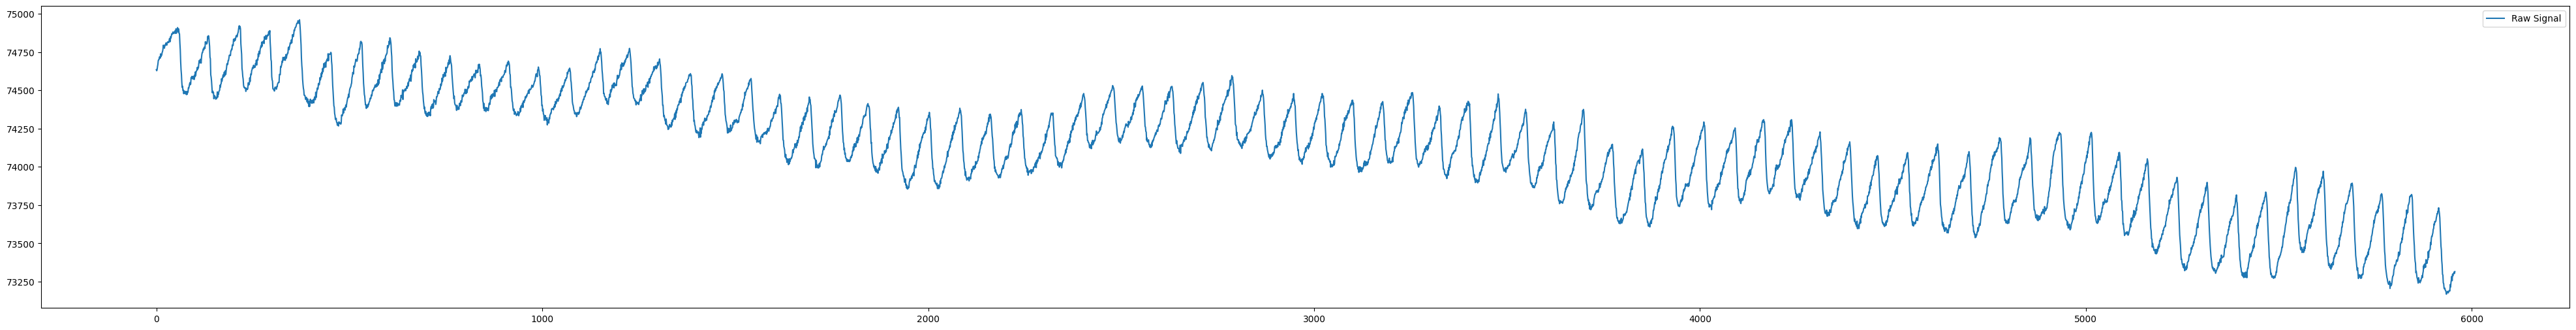

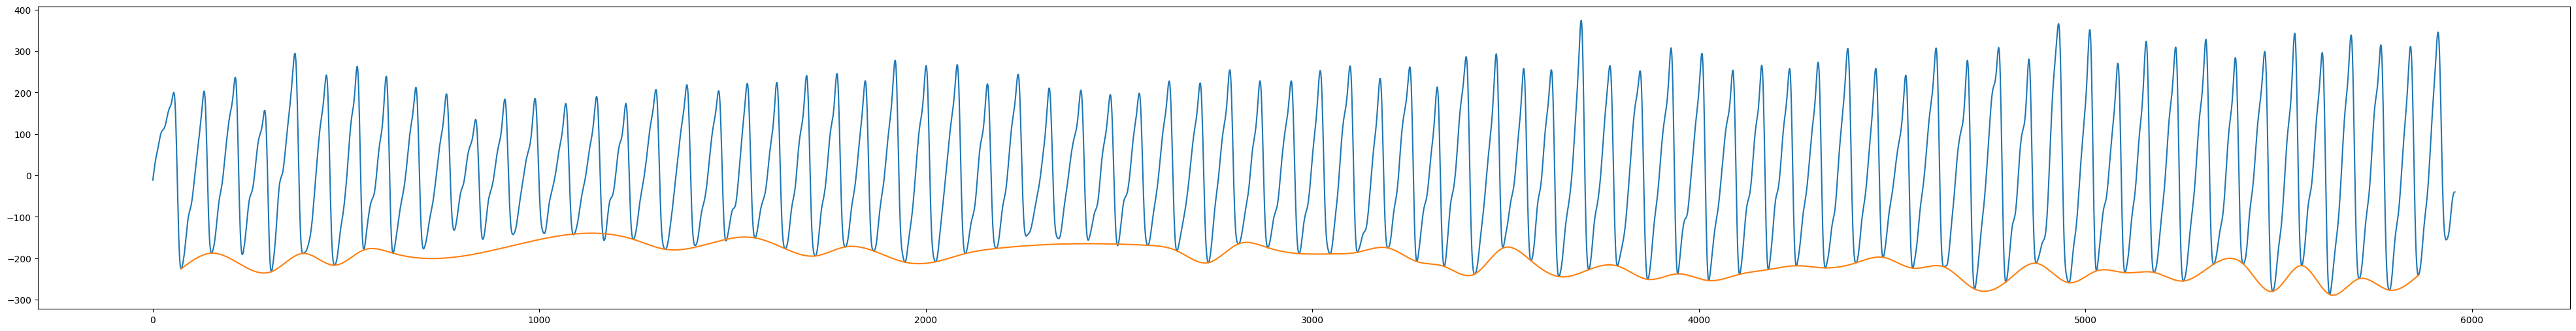

In [49]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler(feature_range=(0, 1))

plt.figure(figsize=(50, 6))
plt.plot(ppgsignals["IR"], label='Raw Signal')
plt.legend()
plt.show()

# plt.figure(figsize=(50, 6))
# plt.plot(ir_signals, label='IR Signal')
# plt.legend()
# plt.show()
plt.figure(figsize=(50, 6))
plt.plot(ir_filt, label='Filtered Signal')
plt.plot(ir_baseline, label='Baseline')
plt.show()
# plt.figure(figsize=(50, 6))
# plt.plot(scaler.fit_transform(ir_detrended.reshape(-1, 1)), label='Detrended Signal')
# plt.show()


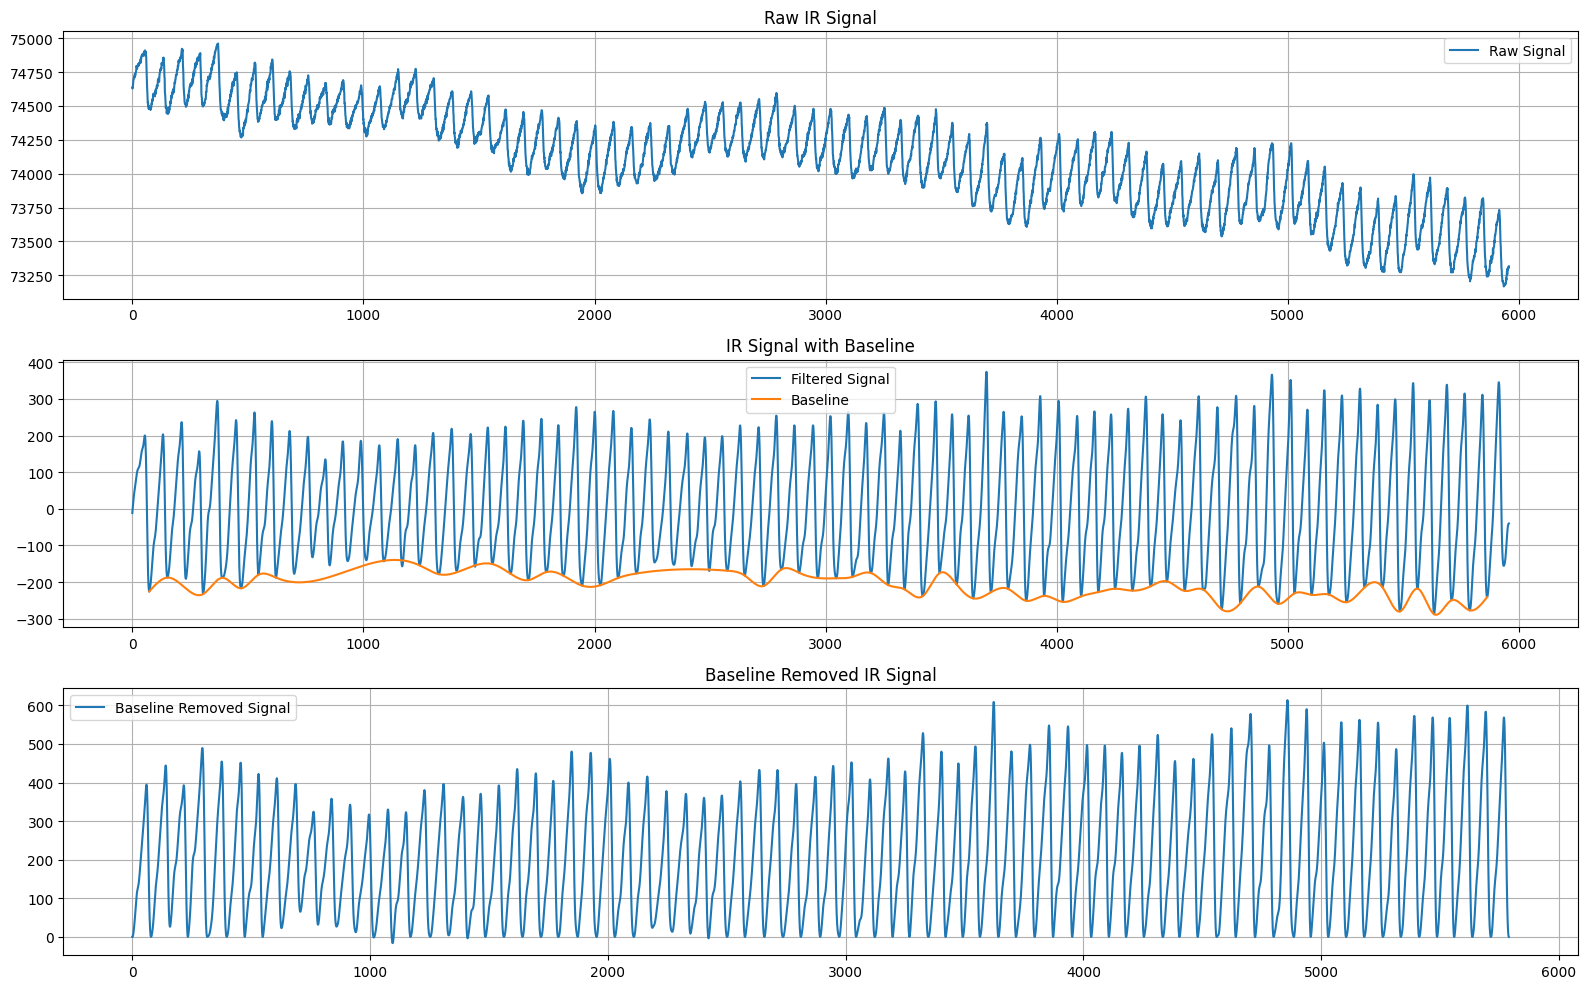

In [50]:
plt.figure(figsize=(16, 10))

# --- Raw Signal ---
plt.subplot(3, 1, 1)
plt.plot(ppgsignals["IR"], label='Raw Signal')
plt.title('Raw IR Signal')
plt.legend()
plt.grid(True)

# --- Filtered + Baseline ---
plt.subplot(3, 1, 2)
plt.plot(ir_filt, label='Filtered Signal')
plt.plot(ir_baseline, label='Baseline')
plt.title('IR Signal with Baseline')
plt.legend()
plt.grid(True)

# --- Baseline Removed ---
plt.subplot(3, 1, 3)
plt.plot(ir_detrended, label='Baseline Removed Signal')
plt.title('Baseline Removed IR Signal')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [51]:
red_valleys, red_peaks, red_filt = detect_valleys_ppg(red_signals, fs=SAMPLE_RATE, low=0.5, high=6.0)
red_detrended, red_baseline, red_segments = spline_baseline_removal_v2(red_filt, red_valleys)

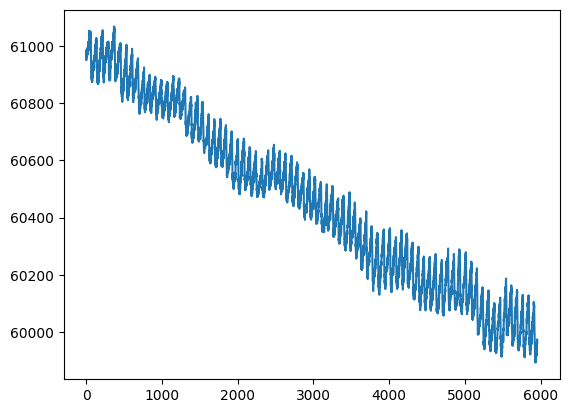

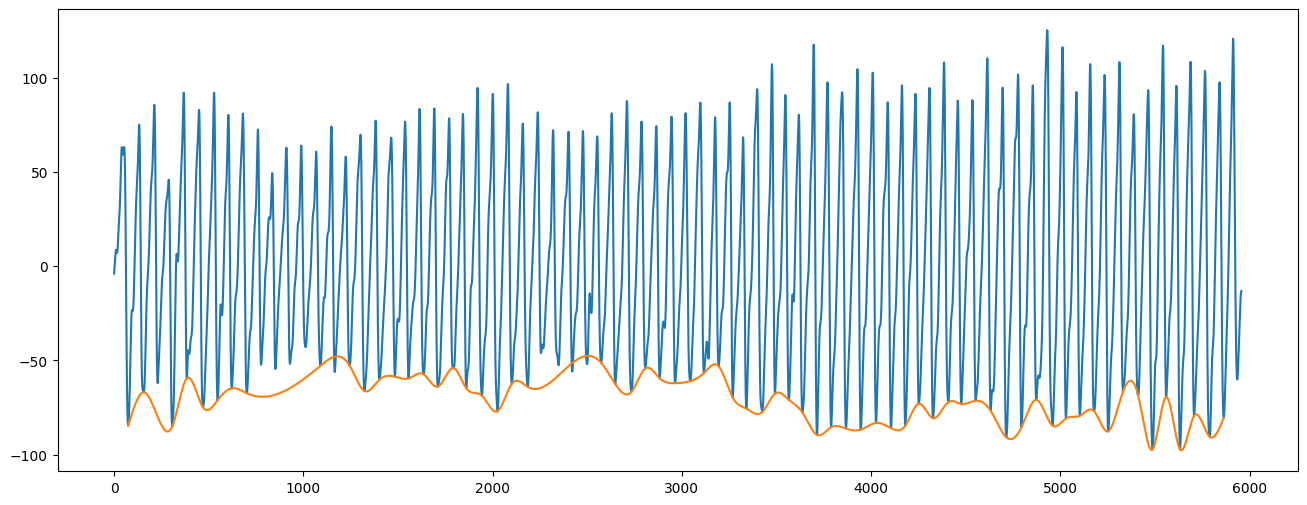

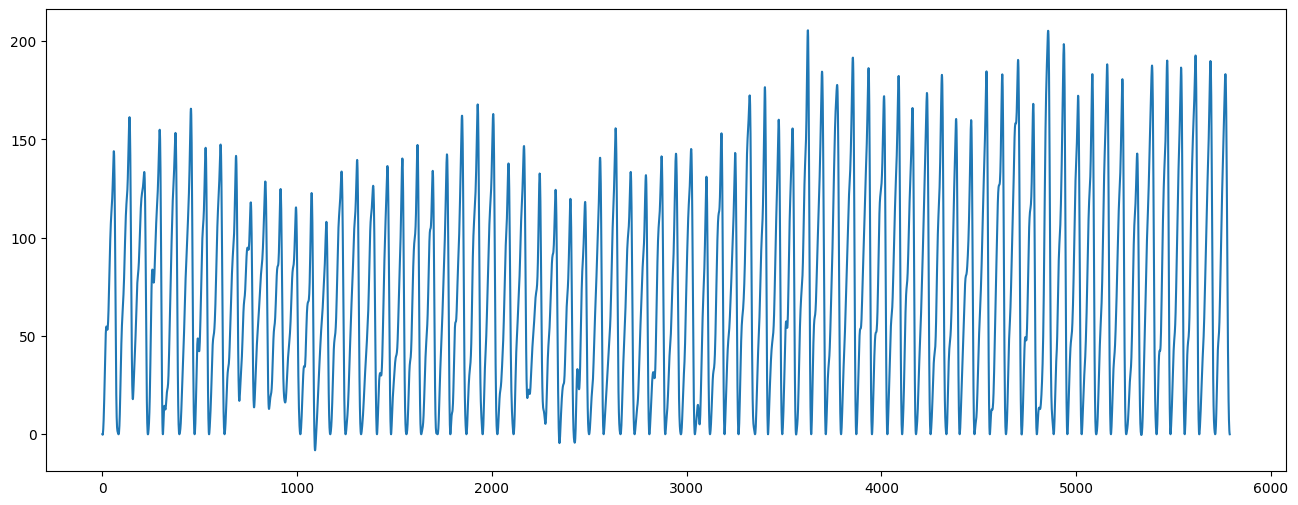

In [52]:
plt.plot(red_signals, label='Red Signal')
plt.show()
plt.figure(figsize=(16, 6))
plt.plot(red_filt, label='Filtered Signal')
plt.plot(red_baseline, label='Baseline')
plt.show()
plt.figure(figsize=(16, 6))
plt.plot(red_detrended, label='Detrended Signal')
plt.show()

In [53]:
UCH_SPO2_TABLE = [
    95, 95, 95, 96, 96, 96, 97, 97, 97, 97, 97, 98, 98, 98, 98, 98, 99, 99, 99, 99,
    99, 99, 99, 99, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
    100, 100, 100, 100, 99, 99, 99, 99, 99, 99, 99, 99, 98, 98, 98, 98, 98, 98, 97, 97,
    97, 97, 96, 96, 96, 96, 95, 95, 95, 94, 94, 94, 93, 93, 93, 92, 92, 92, 91, 91,
    90, 90, 89, 89, 89, 88, 88, 87, 87, 86, 86, 85, 85, 84, 84, 83, 82, 82, 81, 81,
    80, 80, 79, 78, 78, 77, 76, 76, 75, 74, 74, 73, 72, 72, 71, 70, 69, 69, 68, 67,
    66, 66, 65, 64, 63, 62, 62, 61, 60, 59, 58, 57, 56, 56, 55, 54, 53, 52, 51, 50,
    49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 31, 30, 29,
    28, 27, 26, 25, 23, 22, 21, 20, 19, 17, 16, 15, 14, 12, 11, 10, 9, 7, 6, 5,
    3, 2, 1
]

FREQ_S    = 100          # your actual sample rate
BUFFER_S  = FREQ_S * 4  # 400 samples = 4s window
MA4_SIZE  = 4


In [54]:
def _find_valleys(ir_window):
    """
    Port of maxim_find_peaks on the inverted, MA4-filtered IR signal.
    Returns valley locations in the original signal indices.
    """
    n = len(ir_window)

    # Remove DC and invert (so valleys become peaks)
    ir_mean = np.mean(ir_window)
    x = -(ir_window - ir_mean).astype(np.int64)

    # 4-point moving average (same truncation as C code)
    for k in range(n - MA4_SIZE):
        x[k] = int((x[k] + x[k+1] + x[k+2] + x[k+3]) / 4)

    # Threshold (clamped 30–60, same as C)
    n_th1 = int(np.mean(x))
    n_th1 = max(30, min(60, n_th1))

    # Peak detection (peaks above threshold, min distance 4, max 15 peaks)
    min_height   = n_th1
    min_distance = 4
    max_peaks    = 15

    # Find all peaks above min_height
    locs = []
    i = 1
    while i < n - 1:
        if x[i] > min_height and x[i] > x[i-1]:
            width = 1
            while i + width < n and x[i] == x[i + width]:
                width += 1
            if x[i] > x[i + width] and len(locs) < 15:
                locs.append(i)
                i += width + 1
            else:
                i += width
        else:
            i += 1

    # Remove peaks too close together (keep highest, port of maxim_remove_close_peaks)
    if len(locs) > 1:
        # Sort by descending height
        locs_sorted = sorted(locs, key=lambda idx: x[idx], reverse=True)
        kept = []
        for loc in locs_sorted:
            too_close = any(abs(loc - k) <= min_distance for k in kept)
            if not too_close:
                kept.append(loc)
            if len(kept) >= max_peaks:
                break
        locs = sorted(kept)  # back to ascending order

    return locs, x


def compute_spo2_window(ir_window, red_window):
    """
    Compute a single SpO2 value from a 4s window of IR and Red signals.
    Returns (spo2, valid) matching the Maxim algorithm output.
    """
    ir_window  = np.array(ir_window,  dtype=np.int64)
    red_window = np.array(red_window, dtype=np.int64)

    valley_locs, _ = _find_valleys(ir_window)
    n_npks = len(valley_locs)

    if n_npks < 2:
        return -999, 0

    # Use raw IR and Red for AC/DC ratio calculation
    an_x = ir_window.copy()   # IR
    an_y = red_window.copy()  # Red

    ratios = []
    for k in range(n_npks - 1):
        v0 = valley_locs[k]
        v1 = valley_locs[k + 1]

        if v1 - v0 <= 3:
            continue
        if v0 >= BUFFER_S or v1 >= BUFFER_S:
            return -999, 0

        # Find DC max between the two valleys
        x_dc_max     = -16777216
        x_dc_max_idx = v0
        y_dc_max     = -16777216
        y_dc_max_idx = v0

        for i in range(v0, v1):
            if an_x[i] > x_dc_max:
                x_dc_max     = int(an_x[i])
                x_dc_max_idx = i
            if an_y[i] > y_dc_max:
                y_dc_max     = int(an_y[i])
                y_dc_max_idx = i

        # AC component: subtract linear DC trend (port of C formula exactly)
        # Red (y)
        n_y_ac = (int(an_y[v1]) - int(an_y[v0])) * (y_dc_max_idx - v0)
        n_y_ac = int(an_y[v0]) + n_y_ac // (v1 - v0)
        n_y_ac = int(an_y[y_dc_max_idx]) - n_y_ac

        # IR (x) — note: C uses y_dc_max_idx here too (not x_dc_max_idx), matching source
        n_x_ac = (int(an_x[v1]) - int(an_x[v0])) * (x_dc_max_idx - v0)
        n_x_ac = int(an_x[v0]) + n_x_ac // (v1 - v0)
        n_x_ac = int(an_x[y_dc_max_idx]) - n_x_ac

        # Ratio (scaled by >>7 to avoid overflow, same as C)
        # n_nume  = (n_y_ac * x_dc_max) >> 7
        # n_denom = (n_x_ac * y_dc_max) >> 7
        n_nume  = (n_y_ac * x_dc_max)
        n_denom = (n_x_ac * y_dc_max)

        if n_denom > 0 and n_nume != 0 and len(ratios) < 5:
            ratios.append((n_nume * 100) // n_denom)

    if not ratios:
        return -999, 0

    # Median ratio (same logic as C)
    ratios.sort()
    mid = len(ratios) // 2
    if mid > 1:
        ratio_average = (ratios[mid - 1] + ratios[mid]) // 2
    else:
        ratio_average = ratios[mid]
        
    if 2 < ratio_average < 184:
        SpO2 = -45.060 * (ratio_average / 100)  **2 + 30.354 * (ratio_average / 100) + 94.845
        return SpO2, 1
        return UCH_SPO2_TABLE[ratio_average], 1
    else:
        return -999, 0


def compute_spo2_timeseries(ir_signal, red_signal, fs=FREQ_S):
    """
    Slide a 4s window (step = 1s) over the full signal.
    Returns:
        spo2_values : list of SpO2 (or -999 if invalid)
        valid_flags : list of 0/1
        timestamps  : centre time of each window in seconds
    """
    ir_signal  = np.array(ir_signal)
    red_signal = np.array(red_signal)

    window_samples = fs * 4   # 400 @ 100 Hz
    step_samples   = fs * 1   # 100 @ 100 Hz

    spo2_values, valid_flags, timestamps = [], [], []

    n_windows = (len(ir_signal) - window_samples) // step_samples + 1

    for i in range(n_windows):
        start = i * step_samples
        end   = start + window_samples

        ir_win  = ir_signal[start:end]
        red_win = red_signal[start:end]

        spo2, valid = compute_spo2_window(ir_win, red_win)

        centre_time = (start + window_samples / 2) / fs
        spo2_values.append(spo2)
        valid_flags.append(valid)
        timestamps.append(centre_time)

    return spo2_values, valid_flags, timestamps

In [55]:
df = pd.read_csv('test_data.csv')
ir_signal  = df['IR'].values
red_signal = df['RED'].values

spo2_values, valid_flags, timestamps = compute_spo2_timeseries(ir_signal, red_signal, fs=100)

for t, spo2, valid in zip(timestamps, spo2_values, valid_flags):
    status = f"{spo2}%" if valid else "invalid"
    print(f"t={t:.1f}s  SpO2={status}")

t=2.0s  SpO2=97.292136%
t=3.0s  SpO2=98.899554%
t=4.0s  SpO2=70.888584%
t=5.0s  SpO2=96.748986%
t=6.0s  SpO2=99.777%
t=7.0s  SpO2=99.777%
t=8.0s  SpO2=99.777%
t=9.0s  SpO2=99.777%
t=10.0s  SpO2=invalid
t=11.0s  SpO2=invalid
t=12.0s  SpO2=invalid
t=13.0s  SpO2=69.42290399999999%
t=14.0s  SpO2=83.01464999999999%
t=15.0s  SpO2=91.887384%
t=16.0s  SpO2=91.887384%
t=17.0s  SpO2=91.887384%
